# let's try to produce a mbhb

In [ ]:
import fix_cupy  # must be first!
import cupy as cp
print(cp.cuda.runtime.getDeviceCount())  # should be > 0
print(cp.cuda.Device(0).attributes)

import os
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "not set"))
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import PC_SI
from lisatools.detector import EqualArmlengthOrbits

# --- 1. SETUP PARAMETERS ---
dt = 10.0
T_obs_days = 7.5
T_gen_days = 30.0

N_obs = int(T_obs_days * 24 * 3600 / dt)
N_gen = int(T_gen_days * 24 * 3600 / dt)

# IMPORTANT: We must pass CuPy arrays to BBHX when using the GPU backend!
freqs_obs = cp.asarray(np.fft.rfftfreq(N_obs, dt))
freqs_gen = cp.asarray(np.fft.rfftfreq(N_gen, dt))

# Init GPU Orbits and Waveform Generator
# Let the library auto-detect your CUDA version!
orbits = EqualArmlengthOrbits(use_gpu=True) 
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits), force_backend="cuda")


# We use masses where the inspiral lasts longer than 7.5 days!
m1, m2 = 5e5, 1e5  
dist = 10000 * 1e6 * PC_SI
inc, lam, beta, psi, phi_ref = 0.5, 1.0, 0.2, 0.8, 0.0

# We want the merger at exactly Day 26.25 (which is the middle of the 7.5-day window)
t_ref_absolute = 26.25 * 24 * 3600.0

# =====================================================================
# METHOD A: MALVINA'S METHOD (Generate 30 Days -> Slice last 7.5 Days)
# =====================================================================
t0 = time.time()
wave_fd_30 = wave_gen(
    m1, m2, 0.0, 0.0, dist, phi_ref, 0.0, inc, lam, beta, psi, t_ref_absolute,
    freqs=freqs_gen, modes=[(2,2)], direct=False, fill=True, length=1024,
    t_obs_start=0.0, t_obs_end=0.1
)[0, 0, :] 

# Do Inverse FFT on GPU, slice the last 7.5 days, and pull back to CPU (.get()) for plotting!
wave_td_30 = cp.fft.irfft(wave_fd_30, n=N_gen)
wave_td_malvi = wave_td_30[-N_obs:].get() 
time_malvi = time.time() - t0

# =====================================================================
# METHOD B: DIRECT METHOD (Generate 7.5 Days directly)
# =====================================================================
t0 = time.time()
wave_fd_7_5 = wave_gen(
    m1, m2, 0.0, 0.0, dist, phi_ref, 0.0, inc, lam, beta, psi, t_ref_absolute,
    freqs=freqs_obs, modes=[(2,2)], direct=False, fill=True, length=1024,
    t_obs_start=0.0, t_obs_end=1.0
)[0, 0, :] 

# Do Inverse FFT on GPU and pull back to CPU (.get())
wave_td_direct = cp.fft.irfft(wave_fd_7_5, n=N_obs).get()
time_direct = time.time() - t0

# =====================================================================
# PLOTTING AND COMPARISON
# =====================================================================
print(f"Time taken by Malvina's Method (30d + slice): {time_malvi:.4f} seconds")
print(f"Time taken by Direct Method (7.5d directly): {time_direct:.4f} seconds")

time_axis = np.arange(N_obs) * dt / (24 * 3600.0) # 0 to 7.5 days

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time Domain - Malvina
axes[0, 0].plot(time_axis, wave_td_malvi, color='darkorange')
axes[0, 0].set_title("Malvina's Method (Clean Slice)")
axes[0, 0].set_ylabel("Amplitude")

# 2. Time Domain - Direct
axes[0, 1].plot(time_axis, wave_td_direct, color='royalblue')
axes[0, 1].set_title("Direct Method (Note the noise at the right edge!)")

# 3. Spectrogram - Malvina
f_m, t_m, Sxx_m = spectrogram(wave_td_malvi, fs=1.0/dt, nperseg=1024, noverlap=768)
axes[1, 0].pcolormesh(t_m/(24*3600), f_m, np.log10(Sxx_m + 1e-40), shading='gouraud', cmap='viridis')
axes[1, 0].set_ylim(1e-5, 2e-3)
axes[1, 0].set_xlabel("Time [Days]")
axes[1, 0].set_ylabel("Frequency [Hz]")
axes[1, 0].set_title("Spectrogram (Clean Background)")

# 4. Spectrogram - Direct
f_d, t_d, Sxx_d = spectrogram(wave_td_direct, fs=1.0/dt, nperseg=1024, noverlap=768)
axes[1, 1].pcolormesh(t_d/(24*3600), f_d, np.log10(Sxx_d + 1e-40), shading='gouraud', cmap='viridis')
axes[1, 1].set_ylim(1e-5, 2e-3)
axes[1, 1].set_xlabel("Time [Days]")
axes[1, 1].set_title("Spectrogram (Notice the Wrap-Around!)")

plt.tight_layout()
plt.show()

In [ ]:
import cupy as cp
import torch
print("CuPy sees GPU:", cp.cuda.is_available())
print("PyTorch sees GPU:", torch.cuda.is_available())

In [1]:
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import PC_SI
from lisatools.detector import EqualArmlengthOrbits


use_gpu = False  # Set to False to run on CPU (for testing)
xp = cp if use_gpu else np

# ==========================================
# 1. SETUP PARAMETERS & GPU
# ==========================================
dt = 10.0
T_obs_days = 7.5
T_gen_days = 30.0

N_obs = int(T_obs_days * 24 * 3600 / dt)
N_gen = int(T_gen_days * 24 * 3600 / dt)

freqs_obs = xp.asarray(np.fft.rfftfreq(N_obs, dt))
freqs_gen = xp.asarray(np.fft.rfftfreq(N_gen, dt))

# Initialize BBHX (Auto-detects CUDA version, no 'force_backend' errors!)
orbits = EqualArmlengthOrbits(use_gpu=True) 
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits))

# MBHB Parameters (We use a slightly lower mass so the inspiral lasts longer than 7.5 days)
m1, m2 = 3e5, 1e5  
dist = 10000 * 1e6 * PC_SI
inc, lam, beta, psi, phi_ref = 0.5, 1.0, 0.2, 0.8, 0.0

print("Generating waveforms...")

# ==========================================
# METHOD A: YOUR METHOD (30 Days -> Slice)
# ==========================================
t0_A = time.time()
# Merger placed at Day 26.25 (middle of the last 7.5 days)
t_ref_A = 26.25 * 24 * 3600.0

wave_fd_A = wave_gen(
    m1, m2, 0.0, 0.0, dist, phi_ref, 0.0, inc, lam, beta, psi, t_ref_A,
    freqs=freqs_gen, modes=[(2,2)], direct=False, fill=True, length=1024
)[0, 0, :] 

# iFFT on GPU, then slice the last 7.5 days, then pull to CPU
wave_td_A = cp.fft.irfft(wave_fd_A, n=N_gen)[-N_obs:].get() 
time_A = time.time() - t0_A


# ==========================================
# METHOD B: SUPERVISOR'S METHOD (7.5 Days + Shift)
# ==========================================
t0_B = time.time()
# The supervisor generates directly into the 7.5 day array. 
# We place the merger at Day 3.75 (middle of the 7.5 day window)
t_ref_B = 3.75 * 24 * 3600.0

wave_fd_B = wave_gen(
    m1, m2, 0.0, 0.0, dist, phi_ref, 0.0, inc, lam, beta, psi, t_ref_B,
    freqs=freqs_obs, modes=[(2,2)], direct=False, fill=True, length=1024
)[0, 0, :] 

# The supervisor applies an extra shift, which we mimic mathematically here:
# (Shifting it by 5000 seconds just like their code)
shift_sec = 5000.0
phase_shift = cp.exp(-1j * 2.0 * np.pi * freqs_obs * shift_sec)
wave_fd_B *= phase_shift

# iFFT on GPU, pull to CPU
wave_td_B = cp.fft.irfft(wave_fd_B, n=N_obs).get()
time_B = time.time() - t0_B

print(f"-> Your Method time: {time_A:.4f} seconds")
print(f"-> Supervisor's Method time: {time_B:.4f} seconds")


# ==========================================
# PLOTTING
# ==========================================
time_axis = np.arange(N_obs) * dt / (24 * 3600.0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Time Domain Plots ---
axes[0, 0].plot(time_axis, wave_td_A, color='darkorange')
axes[0, 0].set_title("YOUR METHOD: Clean Time Domain")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(time_axis, wave_td_B, color='royalblue')
axes[0, 1].set_title("SUPERVISOR'S METHOD: Look at the edges!")
# Highlight the wrap-around artifact
axes[0, 1].axvspan(6.5, 7.5, color='red', alpha=0.2, label='Wrap-Around Artifact')
axes[0, 1].legend()

# --- Spectrograms (Time-Frequency) ---
f_A, t_A, Sxx_A = spectrogram(wave_td_A, fs=1.0/dt, nperseg=1024, noverlap=800)
axes[1, 0].pcolormesh(t_A/(24*3600), f_A, np.log10(Sxx_A + 1e-40), shading='gouraud', cmap='magma')
axes[1, 0].set_ylim(1e-5, 2e-3) # Zoom into LISA band
axes[1, 0].set_xlabel("Time [Days]")
axes[1, 0].set_ylabel("Frequency [Hz]")
axes[1, 0].set_title("YOUR METHOD: Pristine Spectrogram")

f_B, t_B, Sxx_B = spectrogram(wave_td_B, fs=1.0/dt, nperseg=1024, noverlap=800)
axes[1, 1].pcolormesh(t_B/(24*3600), f_B, np.log10(Sxx_B + 1e-40), shading='gouraud', cmap='magma')
axes[1, 1].set_ylim(1e-5, 2e-3)
axes[1, 1].set_xlabel("Time [Days]")
axes[1, 1].set_title("SUPERVISOR'S METHOD: Ghost Signal Wrap-Around!")

plt.tight_layout()
plt.show()

Generating waveforms...


ImportError: libcufft.so.11: cannot open shared object file: No such file or directory

# check albertos posteriors

/sps/lisaf/mbellotti/anaconda3/envs/cfm_mbhb/lib/python3.12/site-packages/corner/core.py:27: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.ndimage import gaussian_filter


--- Reading Alberto's Posterior File: smbh_pt_8modes_Q3d_290.h5 ---
Loaded 10240 posterior samples after removing burn-in!
Kept 10240 high-quality samples after lnL cut!


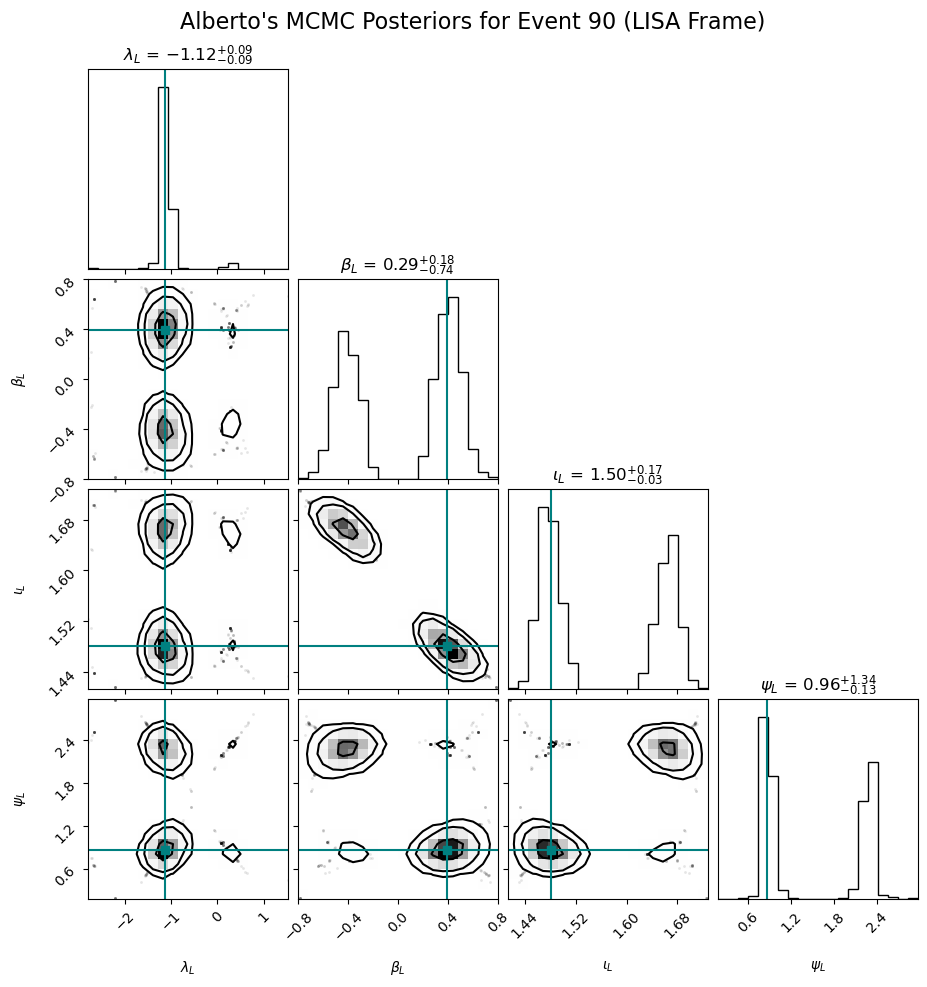

In [1]:
import os
import h5py
import glob
import numpy as np
import corner
import matplotlib.pyplot as plt

repo_path = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 90  # 8-mode event!

h5_matches = glob.glob(os.path.join(repo_path, pop_name, "inference_data", f"*{event_id}*.h5"))
h5_path = h5_matches[0]

print(f"--- Reading Alberto's Posterior File: {os.path.basename(h5_path)} ---")

with h5py.File(h5_path, 'r') as f:
    # 1. EXTRACT TRUE VALUES IN THE LISA FRAME
    true_dict = {}
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            # Handle both scalar values and 1D arrays of length 1
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val
                
    labels = [r"$\lambda_L$", r"$\beta_L$", r"$\iota_L$", r"$\psi_L$"]
    plot_data = []
    truths = []
    
    # 2. EXTRACT CHAINS IN THE LISA FRAME
    for param in ['lambda', 'beta', 'inc', 'psi']:
        # Pull from the 'Lframe' group if it exists, otherwise from the root
        if 'Lframe' in f and param in f['Lframe']:
            chain = f['Lframe'][param][:]
        else:
            chain = f[param][:]
        
        # 3. CRITICAL: CUT THE BURN-IN! (Discard the first 50% of the random walking)
        if len(chain.shape) == 3:
            # (Temperatures, Walkers, Steps) -> Take Coldest Temp, keep second half of steps
            chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2:
            chain_burned = chain[:, chain.shape[1]//2:]
        else:
            chain_burned = chain
            
        plot_data.append(chain_burned.flatten())
        truths.append(true_dict.get(param, 0.0))
        
    samples = np.column_stack(plot_data)
    print(f"Loaded {samples.shape[0]} posterior samples after removing burn-in!")
    
    # 4. FILTER BAD LIKELIHOODS (Exactly what Alberto did in his script!)
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3:
            lnL_burned = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2:
            lnL_burned = lnL[:, lnL.shape[1]//2:].flatten()
        else:
            lnL_burned = lnL
            
        mask = lnL_burned > -40.0
        
        # Make sure mask matches samples size (just in case shapes differ)
        if len(mask) == samples.shape[0]:
            samples = samples[mask]
            print(f"Kept {samples.shape[0]} high-quality samples after lnL cut!")

    # 5. PLOT!
    fig = corner.corner(
        samples, 
        labels=labels, 
        truths=truths,
        truth_color='teal',
        show_titles=True, 
        title_kwargs={"fontsize": 12},
        hist_kwargs={'density': True},
        smooth=0.8,
        fill_contours=False,
        levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-3) )
    )
    fig.suptitle(f"Alberto's MCMC Posteriors for Event {event_id} (LISA Frame)", fontsize=16, y=1.02)
    plt.show()

In [3]:
import sys
import os
import h5py
import json
import glob
import numpy as np

# 1. ADD PATHS SO WE CAN IMPORT YOUR SCRIPT!
TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
sys.path.append(TRAIN_DIR)

# Now we can safely import your dataloader
from train_mbhb_malvi import LISAFlowDataset

# 2. LOAD YOUR DATASET
# (Change this to whatever your latest dataset name is!) /sps/lisaf/mbellotti/github/mbhb_time_frequency/data/dataset_ae_stft_ampl_cross_200k.h5
dataset_path = "/sps/lisaf/mbellotti/github/mbhb_time_frequency/data/dataset_ae_stft_ampl_cross_200k.h5" 
# dataset_path = "data/dataset_stft_fixed_intrinsic_10k.h5"

print(f"--- Loading Dataset: {os.path.basename(dataset_path)} ---")
param_names = ['beta', 'lam', 'inc', 'psi']
dataset = LISAFlowDataset(dataset_path, param_names)

# 3. PRINT DATASET STATISTICS
print("\n--- Dataset Parameter Statistics ---")
for i, name in enumerate(param_names):
    p_mean = dataset.param_mean[i]
    p_std = dataset.param_std[i]
    p_min = np.min(dataset.params[:, i])
    p_max = np.max(dataset.params[:, i])
    print(f"{name:>6}: Mean = {p_mean:>6.3f} | Std = {p_std:>5.3f} | Range = [{p_min:>6.3f}, {p_max:>6.3f}]")

# 4. LOAD ALBERTO'S TRUE EVENT (Let's check Event 55 and Event 1)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"

for event_id in [1, 55, 86]:
    json_matches = glob.glob(os.path.join(alberto_repo, pop_name, "json", f"*{event_id}*.json"))
    if not json_matches:
        continue
        
    with open(json_matches[0], 'r') as f:
        p = json.load(f).get('source_params', {})

    true_inc = float(p.get('inc', p.get('iota', 0.0)))
    true_lam = float(p.get('lam', p.get('phS', p.get('lambda', 0.0))))
    true_beta = np.pi/2.0 - float(p['thS']) if 'thS' in p else float(p.get('beta', 0.0))
    true_psi = float(p.get('psi', p.get('pol', 0.0)))

    true_event = [true_beta, true_lam, true_inc, true_psi]
    
    print(f"\n--- Checking Event {event_id} against Dataset ---")
    for i, name in enumerate(param_names):
        z_score = (true_event[i] - dataset.param_mean[i]) / dataset.param_std[i]
        print(f"{name:>6}: True = {true_event[i]:>6.3f} | Z-Score = {z_score:>5.2f} std devs from mean")
        
        if abs(z_score) > 2.5:
            print(f"       -> [WARNING] {name.upper()} IS AN OUTLIER! The network will be severely biased here.")
        if true_event[i] < np.min(dataset.params[:, i]) or true_event[i] > np.max(dataset.params[:, i]):
            print(f"       -> [FATAL] {name.upper()} is OUTSIDE the training boundaries entirely!")

--- Loading Dataset: dataset_ae_stft_ampl_cross_200k.h5 ---

--- Dataset Parameter Statistics ---
  beta: Mean = -0.000 | Std = 0.683 | Range = [-1.570,  1.570]
   lam: Mean =  3.135 | Std = 1.815 | Range = [-3.138,  6.283]
   inc: Mean =  1.597 | Std = 0.739 | Range = [ 0.000,  3.142]
   psi: Mean =  1.569 | Std = 0.908 | Range = [-3.115,  3.142]

--- Checking Event 1 against Dataset ---
  beta: True =  0.356 | Z-Score =  0.52 std devs from mean
   lam: True =  2.303 | Z-Score = -0.46 std devs from mean
   inc: True =  0.545 | Z-Score = -1.42 std devs from mean
   psi: True =  1.947 | Z-Score =  0.42 std devs from mean

--- Checking Event 55 against Dataset ---
  beta: True = -0.536 | Z-Score = -0.78 std devs from mean
   lam: True =  1.781 | Z-Score = -0.75 std devs from mean
   inc: True =  0.432 | Z-Score = -1.57 std devs from mean
   psi: True = -2.334 | Z-Score = -4.30 std devs from mean
       -> [WARNING] PSI IS AN OUTLIER! The network will be severely biased here.

--- Checkin

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import YRSID_SI

# Setup parameters
dt = 10.0
T_gen = 30 * 24 * 3600.0  # 30 days
T_obs = 7.5 * 24 * 3600.0 # 7.5 days
N_gen = int(T_gen / dt)
N_obs = int(T_obs / dt)
freqs = np.fft.rfftfreq(N_gen, dt)

# Initialize BBHX
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

# Let's say Alberto's JSON says this event merges at exactly Year 2.5
t_ref_true = 2.5 * YRSID_SI

# We want it to appear in our 7.5-day window, exactly 2 days before the window ends
target_time_in_gen_window = T_gen - (2.0 * 24 * 3600.0)

# BBHX needs to know what window of the sky to look at
t_start_yr = (t_ref_true - T_gen) / YRSID_SI
t_end_yr = (t_ref_true + (1.0 * 24 * 3600)) / YRSID_SI

# 1. GENERATE RAW FD WAVEFORM AT YEAR 2.5
# Passed positionally: m1, m2, chi1, chi2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref
wave_fd_out = wave_gen(
    1e6, 2e5, 0.0, 0.0, 1e10,
    0.0, 0.0, np.pi/3, 1.0, 0.5, 0.5, t_ref_true,
    freqs=freqs, modes=[(2,2)], direct=False, fill=True, 
    squeeze=True, length=N_gen, t_obs_start=t_start_yr, t_obs_end=t_end_yr
)

# Extract Channel A
wave_fd_raw = wave_fd_out[0]

# 2. APPLY THE SHIFT
time_shift = t_ref_true - target_time_in_gen_window
phase_shift = np.exp(1j * 2 * np.pi * freqs * time_shift)
wave_fd_shifted = wave_fd_raw * phase_shift

# 3. IFFT BOTH (We slice [-N_obs:] to take the last 7.5 days)
wave_td_raw = np.fft.irfft(wave_fd_raw, n=N_gen)[-N_obs:]
wave_td_shifted = np.fft.irfft(wave_fd_shifted, n=N_gen)[-N_obs:]

# --- PLOTTING ---
fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
time_axis = np.linspace(0, T_obs / (24*3600), N_obs)

# Top Left: Unshifted Time Domain
axs[0,0].plot(time_axis, wave_td_raw, color='red')
axs[0,0].set_title("WITHOUT Shift (Signal wrap-around / destroyed)")
axs[0,0].set_ylabel("Amplitude")

# Top Right: Shifted Time Domain
axs[0,1].plot(time_axis, wave_td_shifted, color='blue')
axs[0,1].set_title("WITH Shift (Perfect Merger in Window!)")

# Bottom Left: Unshifted Spectrogram
f, t, Sxx = spectrogram(wave_td_raw, fs=1/dt, nperseg=1024, noverlap=800)
axs[1,0].pcolormesh(t / (24*3600), f, np.log10(Sxx + 1e-40), shading='gouraud', cmap='viridis')
axs[1,0].set_ylabel("Frequency [Hz]")
axs[1,0].set_xlabel("Time [Days in Window]")
axs[1,0].set_ylim(0, 0.01)

# Bottom Right: Shifted Spectrogram
f, t, Sxx = spectrogram(wave_td_shifted, fs=1/dt, nperseg=1024, noverlap=800)
axs[1,1].pcolormesh(t / (24*3600), f, np.log10(Sxx + 1e-40), shading='gouraud', cmap='viridis')
axs[1,1].set_xlabel("Time [Days in Window]")
axs[1,1].set_ylim(0, 0.01)

plt.tight_layout()
plt.show()

/sps/lisaf/mbellotti/anaconda3/envs/cfm_mbhb/lib/python3.12/site-packages/bbhx/waveformbuild.py:356: SyntaxWarning: invalid escape sequence '\i'
  """Generate the binary black hole frequency-domain TDI waveforms


AttributeError: 'numpy.ndarray' object has no attribute 'get'

In [1]:
import sys
import os
import h5py
import json
import glob
import numpy as np

# 1. ADD PATHS SO WE CAN IMPORT YOUR SCRIPT!
TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
sys.path.append(TRAIN_DIR)

from train_mbhb_malvi import LISAFlowDataset

# 2. LOAD YOUR DATASET
dataset_path = "/sps/lisaf/mbellotti/github/mbhb_time_frequency/data/dataset_ae_stft_ampl_cross_200k.h5" 

print(f"--- Loading Dataset: {os.path.basename(dataset_path)} ---")
param_names = ['beta', 'lam', 'inc', 'psi']
dataset = LISAFlowDataset(dataset_path, param_names)

# 3. PRINT DATASET STATISTICS
print("\n--- Dataset Parameter Statistics ---")
for i, name in enumerate(param_names):
    p_mean = dataset.param_mean[i]
    p_std = dataset.param_std[i]
    p_min = np.min(dataset.params[:, i])
    p_max = np.max(dataset.params[:, i])
    print(f"{name:>6}: Mean = {p_mean:>6.3f} | Std = {p_std:>5.3f} | Range = [{p_min:>6.3f}, {p_max:>6.3f}]")

# 4. LOAD ALBERTO'S TRUE EVENT (Let's check Event 55 and Event 1)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"

print("\n--- Checking True Events against Dataset Distributions ---")
for event_id in [1, 55, 86]:
    json_matches = glob.glob(os.path.join(alberto_repo, pop_name, "json", f"*{event_id}*.json"))
    if not json_matches:
        continue
        
    with open(json_matches[0], 'r') as f:
        p = json.load(f).get('source_params', {})

    # >>> FIXED ANGLE WRAPPING <<<
    true_inc = float(p.get('inc', p.get('iota', 0.0)))
    
    # Lambda usually [0, 2pi]
    true_lam = float(p.get('lam', p.get('phS', p.get('lambda', 0.0)))) % (2 * np.pi)
    
    # Psi usually [0, pi]
    true_psi = float(p.get('psi', p.get('pol', 0.0))) % np.pi
    
    # Beta (Latitude). If the JSON gave colatitude (thS in [0, pi]), we convert it to latitude [-pi/2, pi/2]
    raw_beta = float(p.get('beta', p.get('thS', 0.0)))
    if 'thS' in p or raw_beta > np.pi/2:  
        true_beta = np.pi/2.0 - raw_beta
    else:
        true_beta = raw_beta

    true_event = [true_beta, true_lam, true_inc, true_psi]
    
    print(f"\n-> Event {event_id}:")
    for i, name in enumerate(param_names):
        z_score = (true_event[i] - dataset.param_mean[i]) / dataset.param_std[i]
        print(f"   {name:>4}: True = {true_event[i]:>6.3f} | Z-Score = {z_score:>5.2f} std devs")
        
        if true_event[i] < np.min(dataset.params[:, i]) or true_event[i] > np.max(dataset.params[:, i]):
            print(f"       *** FATAL: {name.upper()} is OUTSIDE the training boundaries! ***")

/sps/lisaf/mbellotti/anaconda3/envs/cfm_mbhb/lib/python3.12/site-packages/astropy/cosmology/_src/scipy_compat.py:10: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.integrate import quad


--- Loading Dataset: dataset_ae_stft_ampl_cross_200k.h5 ---

--- Dataset Parameter Statistics ---
  beta: Mean = -0.000 | Std = 0.683 | Range = [-1.570,  1.570]
   lam: Mean =  3.135 | Std = 1.815 | Range = [-3.138,  6.283]
   inc: Mean =  1.597 | Std = 0.739 | Range = [ 0.000,  3.142]
   psi: Mean =  1.569 | Std = 0.908 | Range = [-3.115,  3.142]

--- Checking True Events against Dataset Distributions ---

-> Event 1:
   beta: True =  0.356 | Z-Score =  0.52 std devs
    lam: True =  2.303 | Z-Score = -0.46 std devs
    inc: True =  0.545 | Z-Score = -1.42 std devs
    psi: True =  1.947 | Z-Score =  0.42 std devs

-> Event 55:
   beta: True = -0.536 | Z-Score = -0.78 std devs
    lam: True =  1.781 | Z-Score = -0.75 std devs
    inc: True =  0.432 | Z-Score = -1.57 std devs
    psi: True =  0.807 | Z-Score = -0.84 std devs

-> Event 86:
   beta: True =  0.787 | Z-Score =  1.15 std devs
    lam: True =  3.145 | Z-Score =  0.01 std devs
    inc: True =  0.729 | Z-Score = -1.17 std devs

In [5]:
import h5py
import numpy as np

# Your fixed ML parameters
target_m1 = 5.00e05
target_dl = 15000.0

# Path to Alberto's summary file
alberto_h5 = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs/data_for_Malvina.h5"

print(f"Hunting for an event close to M1 = {target_m1:.2e} and DL = {target_dl}...\n")

with h5py.File(alberto_h5, 'r') as f:
    for pop_name in ['Q3d', 'Pop3', 'Q3nd']:
        if pop_name not in f: continue
        
        pop_group = f[pop_name]
        results = []
        
        for strid in pop_group.keys():
            ev = pop_group[strid]
            m1 = ev['m1'][()]
            z = ev['z'][()]
            dl = ev['DL_Mpc'][()]
            stsi = int(ev['StSi_index'][()])
            
            # The network sees the detector-frame mass!
            m1_det = m1 * (1 + z) 
            
            # Calculate a normalized distance (so mass and distance are weighted equally)
            diff = ((m1_det - target_m1) / target_m1)**2 + ((dl - target_dl) / target_dl)**2
            
            results.append((diff, stsi, m1_det, dl))
            
        # Sort by closest match
        results.sort(key=lambda x: x[0])
        
        print(f"--- Top 3 closest events in {pop_name} ---")
        for r in results[:3]:
            print(f"Event ID: {r[1]:<4} | M1_det: {r[2]:.2e} M_sun | DL: {r[3]:.2f} Mpc")
        print()

Hunting for an event close to M1 = 5.00e+05 and DL = 15000.0...

--- Top 3 closest events in Q3d ---
Event ID: 282  | M1_det: 4.88e+05 M_sun | DL: 15097.46 Mpc
Event ID: 448  | M1_det: 5.26e+05 M_sun | DL: 15373.24 Mpc
Event ID: 128  | M1_det: 4.93e+05 M_sun | DL: 16529.04 Mpc

--- Top 3 closest events in Pop3 ---
Event ID: 1200 | M1_det: 4.51e+05 M_sun | DL: 15099.39 Mpc
Event ID: 458  | M1_det: 4.21e+05 M_sun | DL: 14705.47 Mpc
Event ID: 1102 | M1_det: 4.52e+05 M_sun | DL: 12134.59 Mpc

--- Top 3 closest events in Q3nd ---
Event ID: 1055 | M1_det: 5.02e+05 M_sun | DL: 15536.74 Mpc
Event ID: 867  | M1_det: 5.02e+05 M_sun | DL: 13092.40 Mpc
Event ID: 1256 | M1_det: 4.35e+05 M_sun | DL: 14302.07 Mpc



In [6]:
import os
import sys
import h5py
import glob
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel

# Import your EXACT dataloader so we get perfect normalization!
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "43338450"
DATASET_NAME = "dataset_ae_stft_phase_50k.h5"

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)

# Alberto's Event
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 282  # <--- The exact StSi index we want to test

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================================================================
# 2. LOAD ALBERTO'S MCMC POSTERIORS & TRUE VALUES FIRST
# ==============================================================================
print(f"\n--- Loading Alberto's MCMC Posteriors for Event {event_id} ---")
# Note: Double check if Alberto's folder is named "data_inference" or "inference_data"!
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "*inference*", f"*{event_id}*.h5"))

if not h5_matches:
    raise FileNotFoundError(f"Could not find Alberto's MCMC file for event {event_id}!")

alberto_path = h5_matches[0]
true_dict = {}
plot_data = []

with h5py.File(alberto_path, 'r') as f:
    # 1. Get Alberto's true injected values
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val
            
    # 2. Extract MCMC chains
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f[param][:]
        
        if len(chain.shape) == 3: chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2: chain_burned = chain[:, chain.shape[1]//2:]
        else: chain_burned = chain[chain.shape[0]//2:]
            
        plot_data.append(chain_burned.flatten())

    alberto_samples = np.column_stack(plot_data)

    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL_burned = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL_burned = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL_burned = lnL[lnL.shape[0]//2:].flatten()
            
        mask = lnL_burned > -40.0
        if len(mask) == alberto_samples.shape[0]:
            alberto_samples = alberto_samples[mask]

# ==============================================================================
# 3. MATCH EVENT IN ML DATASET & CHECK INTRINSIC PARAMS
# ==============================================================================
print(f"\n--- Loading ML Dataset: {DATASET_NAME} ---")
param_names = ['beta', 'lam', 'inc', 'psi']
dataset = LISAFlowDataset(dataset_path, param_names)

# We must search the ML dataset to find the EXACT image that matches Alberto's Event 0
true_lam = true_dict.get('lambda', true_dict.get('lam', 0))
true_beta = true_dict.get('beta', 0)

# Calculate distance between all ML events and Alberto's event
diff = (dataset.raw_param_dict['lam'] - true_lam)**2 + (dataset.raw_param_dict['beta'] - true_beta)**2
best_idx = np.argmin(diff)

print("\n=== INTRINSIC PARAMETER CHECK ===")
ml_m1 = dataset.raw_param_dict['m1'][best_idx]
ml_dist = dataset.raw_param_dict['dist'][best_idx] / (1e6 * PC_SI) # Convert back to Mpc

# If Alberto's file doesn't have m1 natively, we compute it from mchirp and q
if 'm1' in true_dict:
    alberto_m1 = true_dict['m1']
else:
    mc, q_val = true_dict.get('mchirp', 0), true_dict.get('q', 1)
    m_A = mc * (1.0 + q_val)**0.2 / (q_val**0.6)
    alberto_m1 = max(m_A, m_A * q_val)

alberto_dist = true_dict.get('dL', true_dict.get('dist', true_dict.get('DL_Mpc', 0)))
if alberto_dist > 1e6: alberto_dist /= (1e6 * PC_SI) # Ensure it's in Mpc

print(f"Alberto M1: {alberto_m1:.2e} M_sun  | ML Dataset M1: {ml_m1:.2e} M_sun")
print(f"Alberto DL: {alberto_dist:.2f} Mpc | ML Dataset DL: {ml_dist:.2f} Mpc")
print("=================================\n")

# Get the perfectly matched image!
target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)
features_size = len(param_names)

# Crop image
H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

# ==============================================================================
# 4. GENERATE FLOW MATCHING POSTERIORS
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(features_size, 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Running ODE Solver)...")
num_samples = 1000
with torch.no_grad():
    img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
    z0 = torch.randn((num_samples, features_size)).to(device).unsqueeze(1)
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
        z0, torch.linspace(0, 1, 50, device=device), method="euler"
    )
    samples_norm = traj[-1].view(num_samples, features_size).cpu().numpy()

# Un-normalize back to physical parameters
network_samples = samples_norm * dataset.param_std + dataset.param_mean

# ==============================================================================
# 5. PLOT COMPARISON
# ==============================================================================
print("Plotting Comparison...")
labels = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
truths = [true_beta, true_lam, true_dict.get('inc', 0), true_dict.get('psi', 0)]

# 1. Plot Alberto's MCMC (in Blue)
fig = corner.corner(
    alberto_samples,
    labels=labels, 
    truths=truths,
    truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8,
    fill_contours=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

# 2. Overplot Network Posteriors (in Orange)
corner.corner(
    network_samples,  # <--- FIXED SLICE BUG!
    fig=fig, 
    color='darkorange',
    hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

# Custom Legend
custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))

fig.suptitle(f"Posterior Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)
plt.savefig(f"comparison_event_{event_id}.png", dpi=150, bbox_inches='tight')
# print(f"Saved plot to comparison_event_{event_id}.png")


--- Loading Alberto's MCMC Posteriors for Event 282 ---

--- Loading ML Dataset: dataset_ae_stft_phase_50k.h5 ---

=== INTRINSIC PARAMETER CHECK ===
Alberto M1: 4.88e+05 M_sun  | ML Dataset M1: 5.00e+05 M_sun
Alberto DL: 15097.46 Mpc | ML Dataset DL: 15000.00 Mpc

Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Running ODE Solver)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 11.12 GiB. GPU 0 has a total capacity of 31.73 GiB of which 6.20 GiB is free. Including non-PyTorch memory, this process has 25.53 GiB memory in use. Of the allocated memory 22.68 GiB is allocated by PyTorch, and 2.49 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import os
import h5py
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Load Alberto's Intrinsic MCMC parameters
plot_data = []
true_dict = {}

# Make sure you are grabbing 'm1' (or computing it) and 'dL' from Alberto's chains
# These are Frame-Independent!
params_to_compare = ['m1', 'q', 'dL', 'inc'] 
labels = [r"$m_1\ [M_\odot]$", r"$q$", r"$D_L\ [\rm{Mpc}]$", r"$\iota$"]

with h5py.File(alberto_path, 'r') as f:
    # Get truths (Use SSB source_params)
    sp = f['source_params'] if 'source_params' in f else f['source_params_Lframe']
    for k in sp.keys():
        v = sp[k][()]
        true_dict[k] = v[0] if isinstance(v, np.ndarray) else v

    # Extract chains
    for param in params_to_compare:
        # Some lisabeta versions use 'mchirp' instead of 'm1' in the chain
        if param == 'm1' and 'm1' not in f:
            mc_chain = f['mchirp'][:]
            q_chain = f['q'][:]
            mA = mc_chain * (1.0 + q_chain)**0.2 / (q_chain**0.6)
            m1_chain = np.maximum(mA, mA * q_chain)
            chain = m1_chain
        elif param == 'dL' and 'dL' not in f:
            chain = f['dist'][:] if 'dist' in f else f['DL_Mpc'][:]
        else:
            chain = f[param][:]

        # Burn-in
        if len(chain.shape) == 3: chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2: chain_burned = chain[:, chain.shape[1]//2:]
        else: chain_burned = chain[chain.shape[0]//2:]
            
        plot_data.append(chain_burned.flatten())

alberto_samples = np.column_stack(plot_data)

# 2. Extract the corresponding columns from your network samples
# Assuming network_samples columns are: [m1, q, dist_mpc, t_ref, inc, lam, beta, psi]
# Get the indices from your param_names list!
idx_m1 = param_names.index('m1')
idx_q = param_names.index('q')
idx_dist = param_names.index('dist')
idx_inc = param_names.index('inc')

network_plot_samples = np.column_stack([
    network_samples[:, idx_m1],
    network_samples[:, idx_q],
    network_samples[:, idx_dist], # Ensure this is in Mpc!
    network_samples[:, idx_inc]
])

truths = [
    alberto_m1, # calculated previously
    true_dict.get('q', 1.0),
    alberto_dist, # calculated previously
    true_dict.get('inc', 0)
]

# 3. Plot them against each other
fig = corner.corner(alberto_samples, labels=labels, truths=truths, color='royalblue')
corner.corner(network_plot_samples, fig=fig, color='darkorange')
# ... legends ...

In [2]:
import os
import sys
import h5py
import glob
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "42827953"  # Your full parameter space run

DATASET_NAME = "dataset_ae_stft_phase_100k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
# dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"


event_id = 86  # Choose the event you want to compare

device = "cuda" if torch.cuda.is_available() else "cpu"

# The parameters your network predicted
# param_names = ['m1', 'q', 'dist', 'beta', 'lam', 'inc', 'psi']
param_names = ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 2. LOAD ALBERTO'S 4D MCMC POSTERIORS
# ==============================================================================
print(f"--- Loading Extrinsic MCMC Posteriors for Event {event_id} ---")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "*inference*", f"*{event_id}*.h5"))
if not h5_matches: raise FileNotFoundError(f"Could not find MCMC file for event {event_id}!")

mcmc_dict = {}
true_dict = {}

with h5py.File(h5_matches[0], 'r') as f:
    # Get True Values
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val

    # Load only the 4 extrinsic chains
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f.get(param, None)
        if chain is not None:
            if len(chain.shape) == 3: chain = chain[0, :, chain.shape[2]//2:]
            elif len(chain.shape) == 2: chain = chain[:, chain.shape[1]//2:]
            else: chain = chain[chain.shape[0]//2:]
            mcmc_dict[param] = chain.flatten()
            
    # Filter by likelihood
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL = lnL[lnL.shape[0]//2:].flatten()
        mask = lnL > -40.0
        for k in mcmc_dict:
            if len(mcmc_dict[k]) == len(mask):
                mcmc_dict[k] = mcmc_dict[k][mask]

# Stack MCMC into a 4D array: [beta, lam, inc, psi]
mcmc_extrinsic_samples = np.column_stack([
    mcmc_dict['beta'], mcmc_dict['lambda'], mcmc_dict['inc'], mcmc_dict['psi']
])

true_extrinsic = [
    true_dict.get('beta', np.median(mcmc_dict['beta'])),
    true_dict.get('lambda', np.median(mcmc_dict['lambda'])),
    true_dict.get('inc', np.median(mcmc_dict['inc'])),
    true_dict.get('psi', np.median(mcmc_dict['psi']))
]

# ==============================================================================
# 3. FIND EVENT IN ML DATASET & GENERATE FULL 7D POSTERIORS
# ==============================================================================
print(f"\n--- Loading ML Dataset & Finding Event ---")
# Match the event using sky coordinates
diff = (dataset.raw_param_dict['lam'] - true_extrinsic[1])**2 + (dataset.raw_param_dict['beta'] - true_extrinsic[0])**2
best_idx = np.argmin(diff)

target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1500 Network Posteriors...")
num_samples = 1500
with torch.no_grad():
    img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
    z0 = torch.randn((num_samples, len(param_names))).to(device).unsqueeze(1)
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
        z0, torch.linspace(0, 1, 50, device=device), method="euler"
    )
    samples_norm = traj[-1].view(num_samples, len(param_names)).cpu().numpy()

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Convert ML Distance from meters to Mpc for plotting
dist_idx = param_names.index('dist')
ml_samples_full[:, dist_idx] = ml_samples_full[:, dist_idx] / (1e6 * PC_SI)

# Get the True 7D values from the dataset for Plot 1
true_7d_values = dataset.params[best_idx].copy()
true_7d_values[dist_idx] /= (1e6 * PC_SI)  # Also convert the true distance to Mpc

# ==============================================================================
# 4. PLOT 1: ML FULL 7-DIMENSIONAL POSTERIOR
# ==============================================================================
print("Generating Plot 1: Full 7D ML Posterior...")
plot_labels_full = [r"$t_{ref}$", r"$m_1\ [M_\odot]$", r"$m_2\ [M_\odot]$", r"$D_L\ [\rm{Mpc}]$", r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
fig1 = corner.corner(
    ml_samples_full,
    labels=plot_labels_full,
    truths=true_7d_values, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)
fig1.suptitle(f"ML Flow Matching: Full 7D Posterior (Event {event_id})", fontsize=20, y=1.02)
plt.savefig(f"ML_Full_7D_Event_{event_id}.png", dpi=150, bbox_inches='tight')

# ==============================================================================
# 5. PLOT 2: COMPARISON OF THE 4 EXTRINSIC PARAMETERS (ML vs MCMC)
# ==============================================================================
print("Generating Plot 2: 4D Extrinsic Comparison...")

# Slice the ML samples to only get [beta, lam, inc, psi]
# Based on param_names = ['m1', 'q', 'dist', 'beta', 'lam', 'inc', 'psi'], these are indices 3, 4, 5, 6
ml_samples_extrinsic = ml_samples_full[:, 4:8]
plot_labels_extrinsic = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]

fig2 = corner.corner(
    mcmc_extrinsic_samples,
    labels=plot_labels_extrinsic, 
    truths=true_extrinsic, truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

corner.corner(
    ml_samples_extrinsic,
    fig=fig2, 
    color='darkorange',
    hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig2.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))
fig2.suptitle(f"Extrinsic Parameters Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)

plt.savefig(f"Extrinsic_Comparison_Event_{event_id}.png", dpi=150, bbox_inches='tight')

plt.show()
print("Done! Both plots saved.")

/sps/lisaf/mbellotti/anaconda3/envs/cfm_mbhb/lib/python3.12/site-packages/corner/core.py:27: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.ndimage import gaussian_filter


--- Loading Extrinsic MCMC Posteriors for Event 86 ---

--- Loading ML Dataset & Finding Event ---
Loading U-Net Checkpoint...
Generating 1500 Network Posteriors...


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.69 GiB. GPU 0 has a total capacity of 31.73 GiB of which 9.70 GiB is free. Including non-PyTorch memory, this process has 22.03 GiB memory in use. Of the allocated memory 18.56 GiB is allocated by PyTorch, and 3.11 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
import os
import sys
import h5py
import glob
import yaml
import torch
import json
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import PC_SI, YRSID_SI
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb")
from torchcfm.models.unet import UNetModel
from train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS & LOAD ML DATASET NORMALIZATION
# ==============================================================================
JOB_ID = "44168583"  # Your full parameter space run
DATASET_NAME = "dataset_ae_stft_ampl_cross_200k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"

pop_name = "Q3d"
event_id = 1  # Pick ANY event!

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the exact parameter names from YAML
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)

param_names = [key for key, val in config_params['estimate'].items() if val == 1]
print(f"Network was trained on these EXACT parameters: {param_names}")

print(f"Loading Dataset Normalization Statistics from {DATASET_NAME}...")
dataset_stats = LISAFlowDataset(dataset_path, param_names)
x_max = dataset_stats.x_max
param_mean = dataset_stats.param_mean
param_std = dataset_stats.param_std

# ==============================================================================
# 2. EXTRACT TRUE PARAMETERS & GENERATE WAVEFORM
# ==============================================================================
print(f"\n--- Extracting Event {event_id} ---")
json_matches = glob.glob(os.path.join(alberto_repo, pop_name, "json", f"*{event_id}*.json"))
with open(json_matches[0], 'r') as f:
    p = json.load(f).get('source_params', {})

mc, q_json = float(p['Mchirp']), float(p['q'])
m_A = mc * (1.0 + q_json)**0.2 / (q_json**0.6)
true_m1 = max(m_A, m_A * q_json)
true_m2 = min(m_A, m_A * q_json)
true_dist = float(p['dist']) * 1e6 * PC_SI

# ---> CRITICAL FIX: WRAP THE ANGLES SO THEY MATCH YOUR NETWORK [0, 2PI] <---
true_inc = float(p.get('inc', p.get('iota', 0.0)))
true_beta = np.pi/2.0 - float(p['thS']) if 'thS' in p else float(p.get('beta', 0.0))
true_lam = np.mod(float(p.get('lam', p.get('phS', p.get('lambda', 0.0)))), 2 * np.pi)
true_psi = np.mod(float(p.get('psi', p.get('pol', 0.0))), np.pi)
true_phi = float(p.get('phi', p.get('ph0', 0.0)))

dt = 10.0
T_obs, T_gen = 7.5 * 24 * 3600, 30 * 24 * 3600
N_obs, N_gen = int(T_obs / dt), int(T_gen / dt)
true_t_ref = T_gen - (T_obs * 0.1) 

orbits = EqualArmlengthOrbits(use_gpu=True)
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits), force_backend="cuda")

# Generate True Physics Waveform!
freqs_in = np.fft.rfftfreq(N_gen, dt)
wave_out = wave_gen(
    np.array([true_m1]), np.array([true_m2]), np.array([0.0]), np.array([0.0]), np.array([true_dist]),
    np.array([true_phi]), np.array([0.0]), np.array([true_inc]), np.array([true_lam]), np.array([true_beta]), 
    np.array([true_psi]), np.array([true_t_ref]),
    freqs=freqs_in, modes=[(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)], direct=False, fill=True, length=N_gen
)

hA_clean = np.fft.irfft(wave_out[0, 0, :], n=N_gen)[-N_obs:]
hE_clean = np.fft.irfft(wave_out[0, 1, :], n=N_gen)[-N_obs:]

# Exact PSD Whitening
freqs_short = np.fft.rfftfreq(N_obs, dt)
f_safe = np.clip(freqs_short, 1e-5, None)
psd_A = get_sensitivity(f_safe, sens_fn="A1TDISens")
sigma_fd_A = np.sqrt(psd_A / (4 * (1/T_obs)))

hA = np.fft.irfft(np.fft.rfft(hA_clean) / sigma_fd_A, n=N_obs)
hE = np.fft.irfft(np.fft.rfft(hE_clean) / sigma_fd_A, n=N_obs)

# ==========================================================================
# 3. EXACT PYTORCH STFT
# ==========================================================================
mix_torch = torch.tensor(np.stack([hA, hE]), dtype=torch.float32, device=device)
window = torch.hann_window(1024, device=device)
Z_mix = torch.stft(mix_torch, n_fft=1024, hop_length=224, window=window, center=True, return_complex=True, onesided=True)

freqs = np.fft.rfftfreq(1024, d=dt)
mask = (freqs >= 5e-5) & (freqs <= 1e-2)
Z_mix = Z_mix[:, mask, :]

Z_A, Z_E = Z_mix[0], Z_mix[1]
mag_A, mag_E = torch.abs(Z_A), torch.abs(Z_E)
cross_AE = Z_A * torch.conj(Z_E)

cross_norm = cross_AE / (mag_A * mag_E + 1e-30)
log_mag_A = torch.log10(mag_A + 1e-30)
log_mag_E = torch.log10(mag_E + 1e-30)
cos_dphi = torch.real(cross_norm)
sin_dphi = torch.imag(cross_norm)

img = torch.stack([log_mag_A, log_mag_E, cos_dphi, sin_dphi], dim=0).cpu().numpy()

# Normalize
img[:2] = img[:2] / x_max
H, W = img.shape[1], img.shape[2]
H_new, W_new = H - (H % 16), W - (W % 16)
img = img[:, :H_new, :W_new]
img_tensor = torch.tensor(img, dtype=torch.float32, device=device).unsqueeze(0)

# ==============================================================================
# 4. GENERATE POSTERIORS WITH FLOW MATCHING
# ==============================================================================
print("\nLoading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=(img_tensor.shape[1], H_new, W_new), 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (ODE dopri5)...")
num_samples = 1000
batch_size_gen = 50 
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = img_tensor.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # Use Dopri5 for perfect accuracy
        def ode_wrapper(t, x):
            return model.forward(t.expand(x.shape[0]).to(device), x, img_batch, timefrequency=True)
            
        traj = torchdiffeq.odeint(ode_wrapper, z0, torch.linspace(0, 1, 50, device=device), method="dopri5", atol=1e-4, rtol=1e-4)
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

network_samples = np.concatenate(samples_end_list, axis=0) * param_std + param_mean

# ==============================================================================
# 5. LOAD ALBERTO'S MCMC POSTERIORS (AND WRAP THEM!)
# ==============================================================================
print(f"Loading Alberto's MCMC Posteriors for Event {event_id}...")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "inference_data", f"*{event_id}*.h5"))

mcmc_dict = {}
with h5py.File(h5_matches[0], 'r') as f:
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f.get(param, None)
        if chain is not None:
            if len(chain.shape) == 3: chain = chain[0, :, chain.shape[2]//2:]
            elif len(chain.shape) == 2: chain = chain[:, chain.shape[1]//2:]
            else: chain = chain[chain.shape[0]//2:]
            mcmc_dict[param] = chain.flatten()
            
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL = lnL[lnL.shape[0]//2:].flatten()
        mask = lnL > -40.0
        for k in mcmc_dict:
            if len(mcmc_dict[k]) == len(mask):
                mcmc_dict[k] = mcmc_dict[k][mask]

# ---> CRITICAL FIX: WRAP ALBERTO'S MCMC TO MATCH YOUR NETWORK! <---
mcmc_dict['lambda'] = np.mod(mcmc_dict['lambda'], 2 * np.pi)
mcmc_dict['psi'] = np.mod(mcmc_dict['psi'], np.pi)

mcmc_extrinsic_samples = np.column_stack([
    mcmc_dict['beta'], mcmc_dict['lambda'], mcmc_dict['inc'], mcmc_dict['psi']
])
true_extrinsic = [true_beta, true_lam, true_inc, true_psi]

# ==============================================================================
# 6. PLOT EXTRINSIC COMPARISON
# ==============================================================================
print("Generating Extrinsic Comparison Plot...")

idx_beta = param_names.index('beta')
idx_lam = param_names.index('lam')
idx_inc = param_names.index('inc')
idx_psi = param_names.index('psi')
ml_samples_extrinsic = network_samples[:, [idx_beta, idx_lam, idx_inc, idx_psi]]

plot_labels_extrinsic = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]

# Calculate dynamic bounds that include both datasets safely
plot_ranges = []
for i in range(4):
    p_min = min(np.min(mcmc_extrinsic_samples[:, i]), np.min(ml_samples_extrinsic[:, i]))
    p_max = max(np.max(mcmc_extrinsic_samples[:, i]), np.max(ml_samples_extrinsic[:, i]))
    buff = (p_max - p_min) * 0.05
    plot_ranges.append((p_min - buff, p_max + buff))

fig2 = corner.corner(
    mcmc_extrinsic_samples,
    labels=plot_labels_extrinsic, truths=true_extrinsic, truth_color='black',
    color='royalblue', hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    range=plot_ranges, smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

corner.corner(
    ml_samples_extrinsic,
    fig=fig2, color='darkorange',
    range=plot_ranges, hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig2.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))
fig2.suptitle(f"Extrinsic Parameters Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)

plt.savefig(f"OnTheFly_Comparison_Event_{event_id}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Plot saved.")

Network was trained on these EXACT parameters: ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']
Loading Dataset Normalization Statistics from dataset_ae_stft_ampl_cross_200k.h5...

--- Extracting Event 1 ---


ValueError: Tobs entered incorrectly.

In [7]:
import os
import sys
import h5py
import glob
import yaml
import torch
import json
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from scipy.signal import stft

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import PC_SI, YRSID_SI
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb")
from torchcfm.models.unet import UNetModel
from train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS & LOAD ML DATASET NORMALIZATION
# ==============================================================================
JOB_ID = "44168583"  # Your full parameter space run
DATASET_NAME = "dataset_ae_stft_ampl_cross_200k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"

pop_name = "Q3d"
event_id = 1  # Pick ANY event!

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the exact parameter names from YAML
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)

param_names = [key for key, val in config_params['estimate'].items() if val == 1]
print(f"Network was trained on these EXACT parameters: {param_names}")

print(f"Loading Dataset Normalization Statistics from {DATASET_NAME}...")
dataset_stats = LISAFlowDataset(dataset_path, param_names)
x_max = dataset_stats.x_max
param_mean = dataset_stats.param_mean
param_std = dataset_stats.param_std

# ==============================================================================
# 2. EXTRACT TRUE PARAMETERS & GENERATE WAVEFORM
# ==============================================================================
print(f"\n--- Extracting Event {event_id} ---")
json_matches = glob.glob(os.path.join(alberto_repo, pop_name, "json", f"*{event_id}*.json"))
with open(json_matches[0], 'r') as f:
    p = json.load(f).get('source_params', {})

mc, q_json = float(p['Mchirp']), float(p['q'])
m_A = mc * (1.0 + q_json)**0.2 / (q_json**0.6)
true_m1 = max(m_A, m_A * q_json)
true_m2 = min(m_A, m_A * q_json)
true_dist = float(p['dist']) * 1e6 * PC_SI

# ---> CRITICAL FIX: WRAP THE ANGLES SO THEY MATCH YOUR NETWORK [0, 2PI] <---
true_inc = float(p.get('inc', p.get('iota', 0.0)))
true_beta = np.pi/2.0 - float(p['thS']) if 'thS' in p else float(p.get('beta', 0.0))
true_lam = np.mod(float(p.get('lam', p.get('phS', p.get('lambda', 0.0)))), 2 * np.pi)
true_psi = np.mod(float(p.get('psi', p.get('pol', 0.0))), np.pi)
true_phi = float(p.get('phi', p.get('ph0', 0.0)))

dt = 10.0
T_obs, T_gen = 7.5 * 24 * 3600, 30 * 24 * 3600
N_obs, N_gen = int(T_obs / dt), int(T_gen / dt)
true_t_ref = T_gen - (T_obs * 0.1) 

orbits = EqualArmlengthOrbits(use_gpu=True)
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits), force_backend="cuda")

# Generate True Physics Waveform!
freqs_in = np.fft.rfftfreq(N_gen, dt)
wave_out = wave_gen(
    np.array([true_m1]), np.array([true_m2]), np.array([0.0]), np.array([0.0]), np.array([true_dist]),
    np.array([true_phi]), np.array([0.0]), np.array([true_inc]), np.array([true_lam]), np.array([true_beta]), 
    np.array([true_psi]), np.array([true_t_ref]),
    freqs=freqs_in, modes=[(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)], direct=False, fill=True, length=N_gen,
    t_obs_start=0.0, t_obs_end=T_gen/YRSID_SI     # <--- ADDED THESE BACK IN!
)

hA_clean = np.fft.irfft(wave_out[0, 0, :], n=N_gen)[-N_obs:]
hE_clean = np.fft.irfft(wave_out[0, 1, :], n=N_gen)[-N_obs:]

# Exact PSD Whitening
freqs_short = np.fft.rfftfreq(N_obs, dt)
f_safe = np.clip(freqs_short, 1e-5, None)
psd_A = get_sensitivity(f_safe, sens_fn="A1TDISens")
sigma_fd_A = np.sqrt(psd_A / (4 * (1/T_obs)))

hA = np.fft.irfft(np.fft.rfft(hA_clean) / sigma_fd_A, n=N_obs)
hE = np.fft.irfft(np.fft.rfft(hE_clean) / sigma_fd_A, n=N_obs)

# ==========================================================================
# 3. EXACT PYTORCH STFT
# ==========================================================================
mix_torch = torch.tensor(np.stack([hA, hE]), dtype=torch.float32, device=device)
window = torch.hann_window(1024, device=device)
Z_mix = torch.stft(mix_torch, n_fft=1024, hop_length=224, window=window, center=True, return_complex=True, onesided=True)

freqs = np.fft.rfftfreq(1024, d=dt)
mask = (freqs >= 5e-5) & (freqs <= 1e-2)
Z_mix = Z_mix[:, mask, :]

Z_A, Z_E = Z_mix[0], Z_mix[1]
mag_A, mag_E = torch.abs(Z_A), torch.abs(Z_E)
cross_AE = Z_A * torch.conj(Z_E)

cross_norm = cross_AE / (mag_A * mag_E + 1e-30)
log_mag_A = torch.log10(mag_A + 1e-30)
log_mag_E = torch.log10(mag_E + 1e-30)
cos_dphi = torch.real(cross_norm)
sin_dphi = torch.imag(cross_norm)

img = torch.stack([log_mag_A, log_mag_E, cos_dphi, sin_dphi], dim=0).cpu().numpy()

# Normalize
img[:2] = img[:2] / x_max
H, W = img.shape[1], img.shape[2]
H_new, W_new = H - (H % 16), W - (W % 16)
img = img[:, :H_new, :W_new]
img_tensor = torch.tensor(img, dtype=torch.float32, device=device).unsqueeze(0)

# ==============================================================================
# 4. GENERATE POSTERIORS WITH FLOW MATCHING
# ==============================================================================
print("\nLoading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=(img_tensor.shape[1], H_new, W_new), 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (ODE dopri5)...")
num_samples = 1000
batch_size_gen = 50 
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = img_tensor.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # Use Dopri5 for perfect accuracy
        def ode_wrapper(t, x):
            return model.forward(t.expand(x.shape[0]).to(device), x, img_batch, timefrequency=True)
            
        traj = torchdiffeq.odeint(ode_wrapper, z0, torch.linspace(0, 1, 50, device=device), method="dopri5", atol=1e-4, rtol=1e-4)
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

network_samples = np.concatenate(samples_end_list, axis=0) * param_std + param_mean

# ==============================================================================
# 5. LOAD ALBERTO'S MCMC POSTERIORS (AND WRAP THEM!)
# ==============================================================================
print(f"Loading Alberto's MCMC Posteriors for Event {event_id}...")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "inference_data", f"*{event_id}*.h5"))

mcmc_dict = {}
with h5py.File(h5_matches[0], 'r') as f:
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f.get(param, None)
        if chain is not None:
            if len(chain.shape) == 3: chain = chain[0, :, chain.shape[2]//2:]
            elif len(chain.shape) == 2: chain = chain[:, chain.shape[1]//2:]
            else: chain = chain[chain.shape[0]//2:]
            mcmc_dict[param] = chain.flatten()
            
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL = lnL[lnL.shape[0]//2:].flatten()
        mask = lnL > -40.0
        for k in mcmc_dict:
            if len(mcmc_dict[k]) == len(mask):
                mcmc_dict[k] = mcmc_dict[k][mask]

# ---> CRITICAL FIX: WRAP ALBERTO'S MCMC TO MATCH YOUR NETWORK! <---
mcmc_dict['lambda'] = np.mod(mcmc_dict['lambda'], 2 * np.pi)
mcmc_dict['psi'] = np.mod(mcmc_dict['psi'], np.pi)

mcmc_extrinsic_samples = np.column_stack([
    mcmc_dict['beta'], mcmc_dict['lambda'], mcmc_dict['inc'], mcmc_dict['psi']
])
true_extrinsic = [true_beta, true_lam, true_inc, true_psi]

# ==============================================================================
# 6. PLOT EXTRINSIC COMPARISON
# ==============================================================================
print("Generating Extrinsic Comparison Plot...")

idx_beta = param_names.index('beta')
idx_lam = param_names.index('lam')
idx_inc = param_names.index('inc')
idx_psi = param_names.index('psi')
ml_samples_extrinsic = network_samples[:, [idx_beta, idx_lam, idx_inc, idx_psi]]

plot_labels_extrinsic = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]

# Calculate dynamic bounds that include both datasets safely
plot_ranges = []
for i in range(4):
    p_min = min(np.min(mcmc_extrinsic_samples[:, i]), np.min(ml_samples_extrinsic[:, i]))
    p_max = max(np.max(mcmc_extrinsic_samples[:, i]), np.max(ml_samples_extrinsic[:, i]))
    buff = (p_max - p_min) * 0.05
    plot_ranges.append((p_min - buff, p_max + buff))

fig2 = corner.corner(
    mcmc_extrinsic_samples,
    labels=plot_labels_extrinsic, truths=true_extrinsic, truth_color='black',
    color='royalblue', hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    range=plot_ranges, smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

corner.corner(
    ml_samples_extrinsic,
    fig=fig2, color='darkorange',
    range=plot_ranges, hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig2.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))
fig2.suptitle(f"Extrinsic Parameters Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)

plt.savefig(f"OnTheFly_Comparison_Event_{event_id}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Plot saved.")

Network was trained on these EXACT parameters: ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']
Loading Dataset Normalization Statistics from dataset_ae_stft_ampl_cross_200k.h5...

--- Extracting Event 1 ---


ValueError: Tobs entered incorrectly.

# looking only at mine !!!

Network was trained on these EXACT parameters: ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

--- Finding the optimal ML Validation Event ---
Evaluating ML Event Index: 26024
Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (In batches of 50 to prevent memory issues)...
Generating Plot 1: Full ML Posterior...


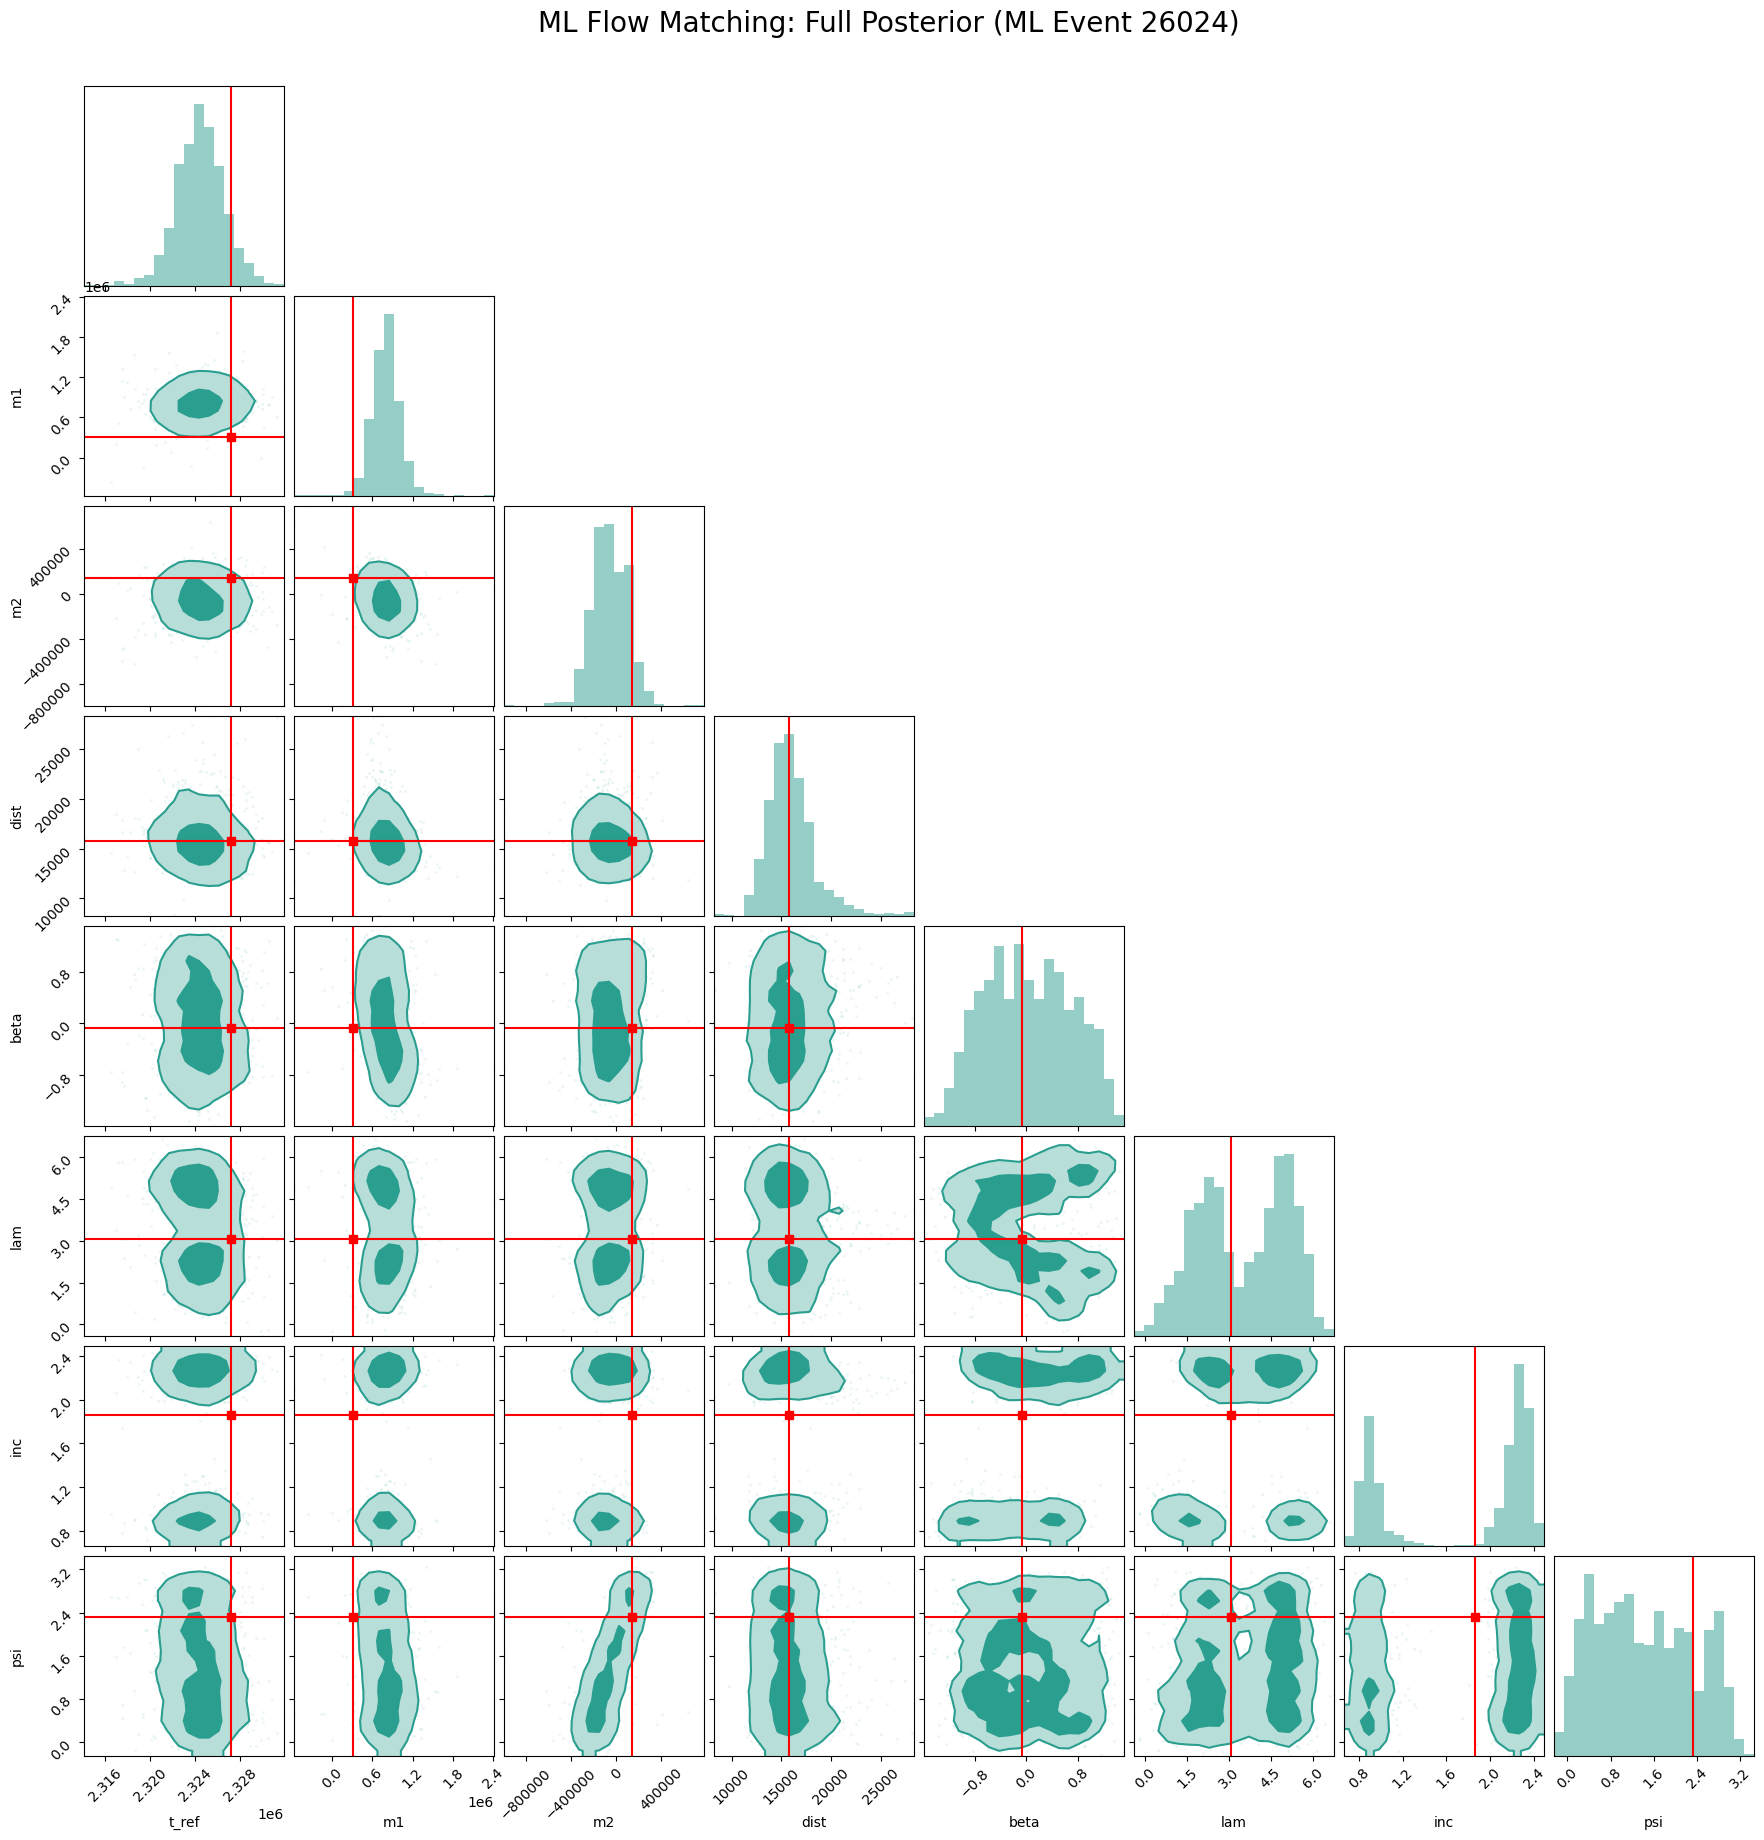

Done!


In [6]:
import os
import sys
import h5py
import glob
import yaml  # <--- WE NEED THIS TO GET THE CORRECT PARAMETER ORDER!
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
# JOB_ID = "42827953"  
# DATASET_NAME = "dataset_ae_stft_phase_100k.h5" 

# TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
# checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
# dataset_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)


JOB_ID = "44168583"  # Your full parameter space run
DATASET_NAME = "dataset_ae_stft_ampl_cross_200k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"



device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================================================================
# 2. GET THE EXACT PARAMETER ORDER FROM YAML
# ==============================================================================
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)

param_names = [key for key, val in config_params['estimate'].items() if val == 1]
print(f"Network was trained on these EXACT parameters: {param_names}")

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 3. FIND THE EXACT EVENT FROM YOUR VALIDATION LOOP
# ==============================================================================
print(f"\n--- Finding the optimal ML Validation Event ---")
# Let's find the exact event your validation script plotted to prove it works!
from astropy.cosmology import Planck18

m1_raw = dataset.raw_param_dict['m1']
q_raw  = dataset.raw_param_dict['q']
dist_raw = dataset.raw_param_dict['dist']
lam_raw = dataset.raw_param_dict['lam']
beta_raw = dataset.raw_param_dict['beta']

mtot_raw = m1_raw * (1 + q_raw)

target_z = 2.0
target_mtot = 5e5 
dl_mpc = Planck18.luminosity_distance(target_z).value
target_dist = dl_mpc * 1e6 * PC_SI 

score = (
    ((np.log10(mtot_raw) - np.log10(target_mtot)) / 1.0)**2 + 
    ((np.log10(dist_raw) - np.log10(target_dist)) / 0.5)**2 + 
    ((lam_raw - np.pi) / np.pi)**2 + 
    ((beta_raw - 0.0) / (np.pi/2))**2
)

best_idx = np.argmin(score)
print(f"Evaluating ML Event Index: {best_idx}")

# ==============================================================================
# 4. GENERATE POSTERIORS
# ==============================================================================
target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (In batches of 50 to prevent memory issues)...")
num_samples = 1000
batch_size_gen = 50
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 50, device=device), method="euler"
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

samples_norm = np.concatenate(samples_end_list, axis=0)

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Get true values
true_7d_values = dataset.params[best_idx].copy()

# Fix Distance Scaling for both prediction and truth if 'dist' is in the list
if 'dist' in param_names:
    dist_idx = param_names.index('dist')
    ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
    true_7d_values[dist_idx] /= (1e6 * PC_SI)

# ==============================================================================
# 5. PLOT ML ONLY (NO ALBERTO COMPARISON YET)
# ==============================================================================
print("Generating Plot 1: Full ML Posterior...")
fig1 = corner.corner(
    ml_samples_full,
    labels=param_names, # Use the exact names loaded from YAML
    truths=true_7d_values, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)
fig1.suptitle(f"ML Flow Matching: Full Posterior (ML Event {best_idx})", fontsize=20, y=1.02)
plt.savefig(f"ML_Only_Event_{best_idx}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

Loading Dataset dataset_ae_stft_ampl_cross_200k.h5...

--- Evaluating ML Validation Event 500328 ---
Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Using dopri5)...
Plotting Results...


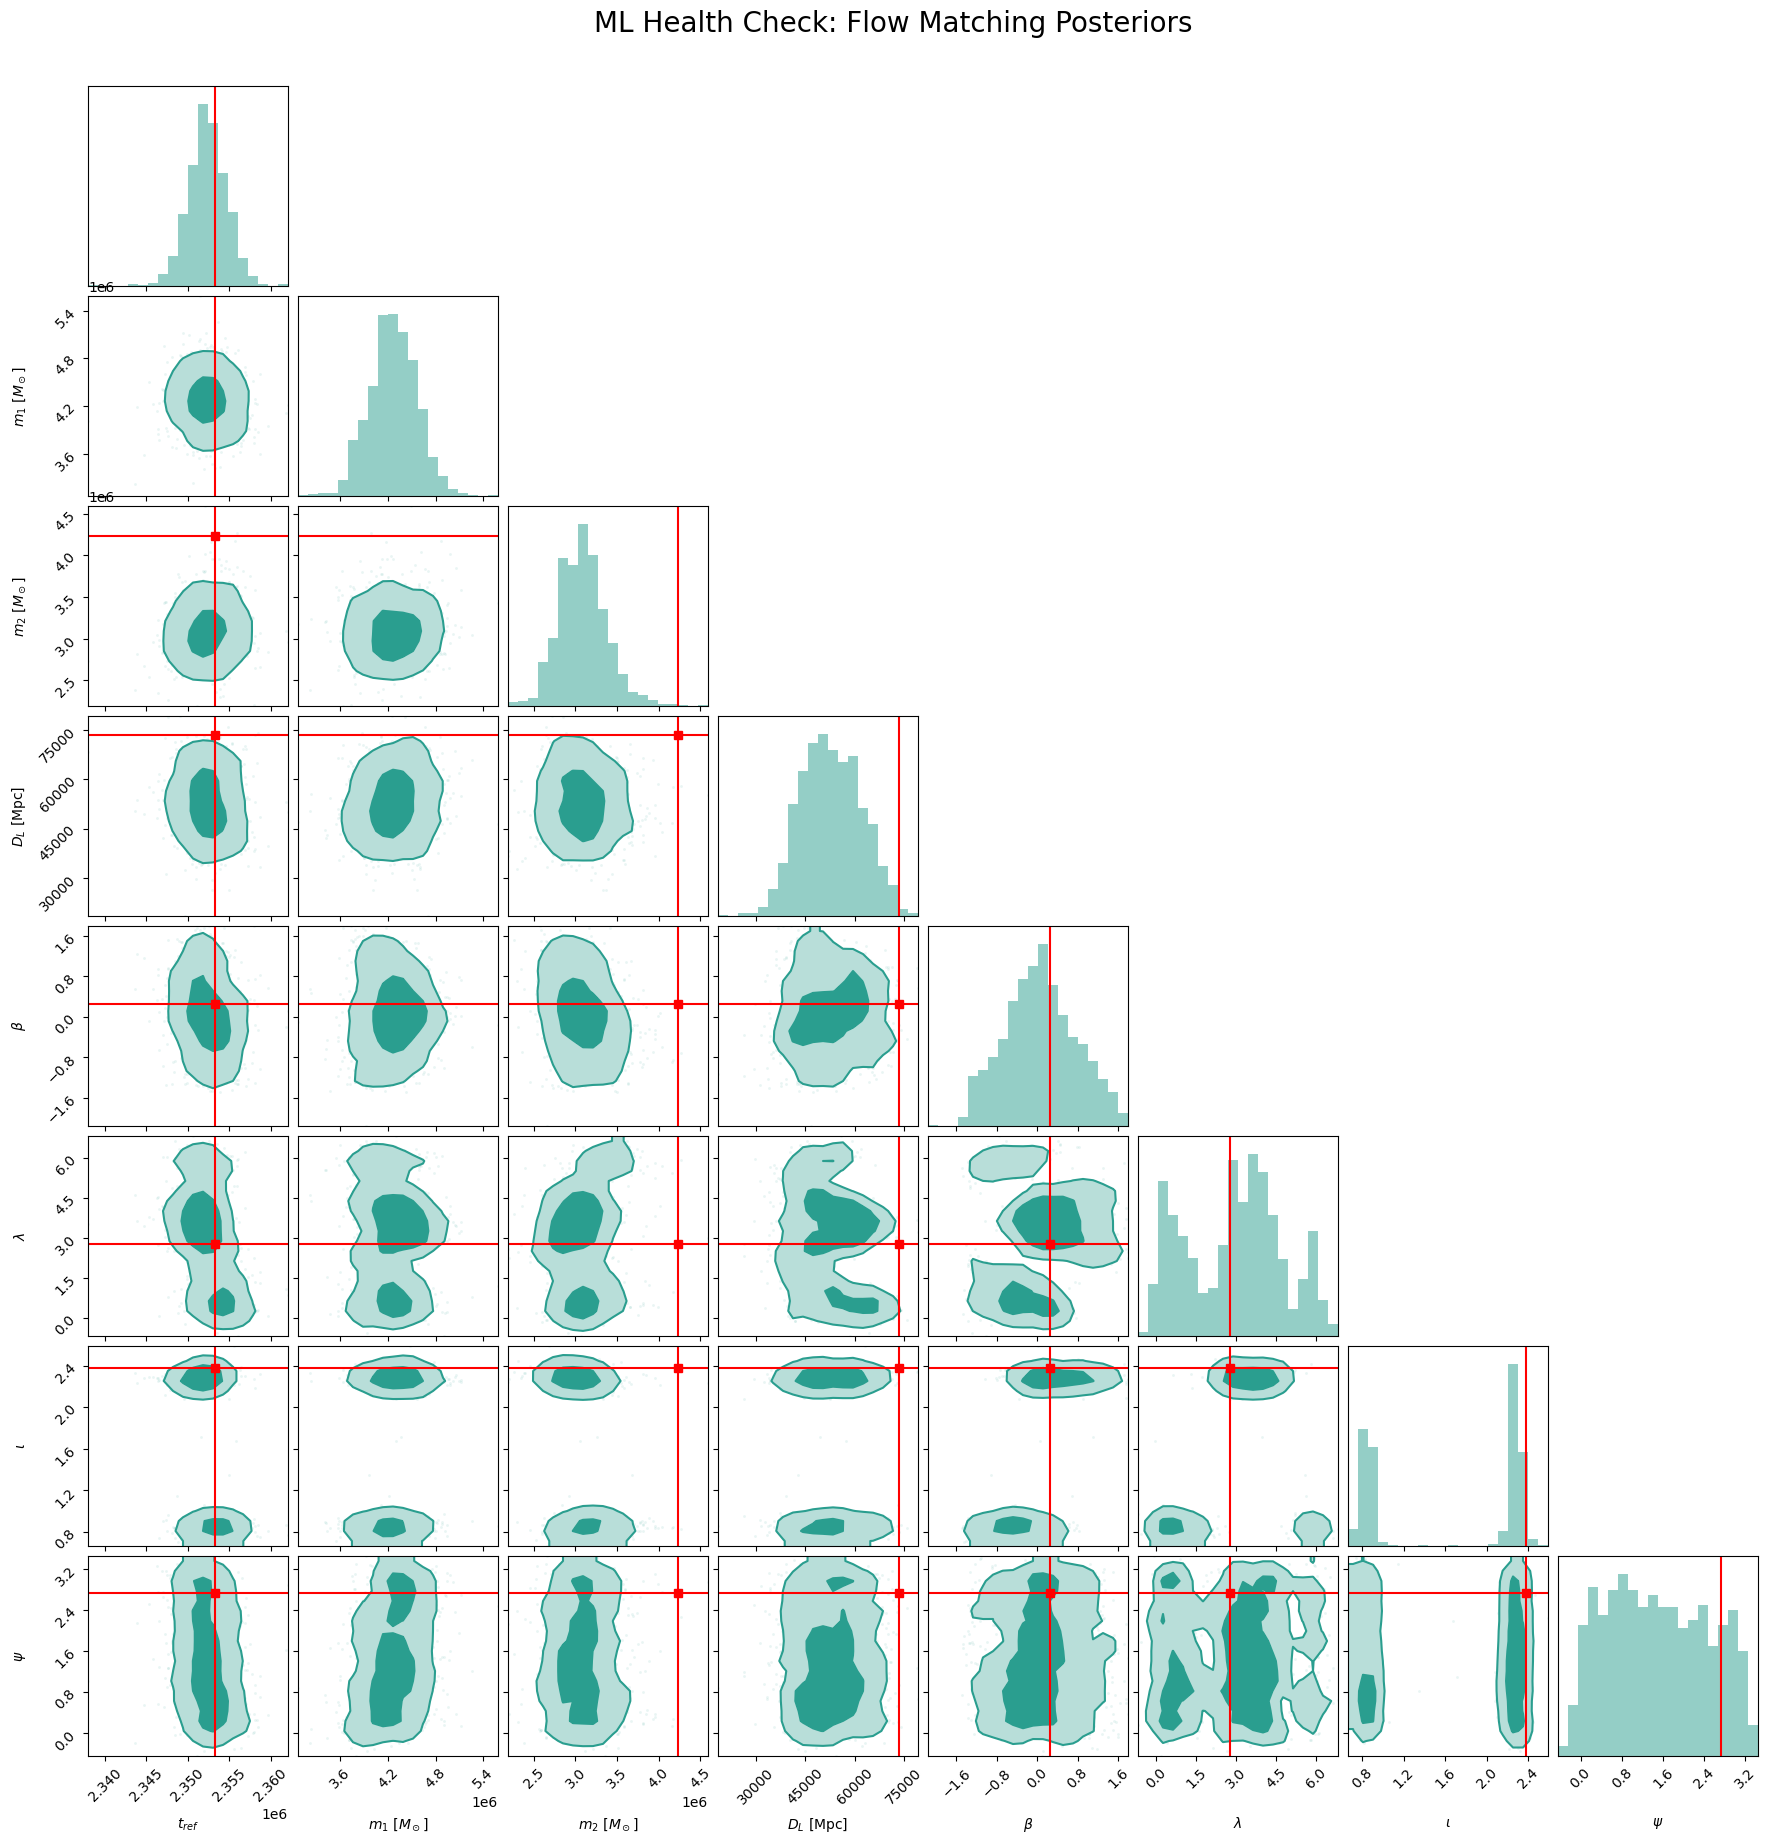

Done! Look at the plot!


In [11]:
import os
import sys
import h5py
import yaml
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "44168583"  
DATASET_NAME = "dataset_ae_stft_ampl_cross_200k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the exact parameter names from YAML
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)
param_names = [key for key, val in config_params['estimate'].items() if val == 1]

print(f"Loading Dataset {DATASET_NAME}...")
dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 2. GRAB A RANDOM VALIDATION EVENT
# ==============================================================================
# Let's pick an event near the end of the dataset (a validation event)
test_idx = len(dataset) - 5 
print(f"\n--- Evaluating ML Validation Event {test_idx} ---")

# Extract the EXACT image and the EXACT true parameters for this event!
target_params_norm, target_img_norm = dataset[test_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

true_physical_params = dataset.params[test_idx].copy()
if 'dist' in param_names:
    dist_idx = param_names.index('dist')
    true_physical_params[dist_idx] /= (1e6 * PC_SI) # Convert to Mpc

# Pad to U-Net requirements
H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

# ==============================================================================
# 3. GENERATE POSTERIORS WITH HIGH PRECISION
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Using dopri5)...")
num_samples = 1000
batch_size_gen = 50 
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # ---> CRITICAL ODE SOLVER FIX! <---
        def ode_wrapper(t, x):
            t_batched = t.expand(x.shape[0]).to(device)
            return model.forward(t_batched, x, img_batch, timefrequency=True)

        traj = torchdiffeq.odeint(
            ode_wrapper, 
            z0, torch.linspace(0, 1, 100, device=device), 
            method="dopri5", atol=1e-4, rtol=1e-4
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

# Un-normalize back to physical parameters
samples_norm = np.concatenate(samples_end_list, axis=0)
network_samples = samples_norm * dataset.param_std + dataset.param_mean

if 'dist' in param_names:
    network_samples[:, dist_idx] /= (1e6 * PC_SI)

# ==============================================================================
# 4. PLOT ML POSTERIOR VS ML TRUTH
# ==============================================================================
print("Plotting Results...")


plot_labels = []
for p in param_names:
    if p == 'm1': plot_labels.append(r"$m_1\ [M_\odot]$")
    elif p == 'm2': plot_labels.append(r"$m_2\ [M_\odot]$")
    elif p == 'dist': plot_labels.append(r"$D_L\ [\rm{Mpc}]$")
    elif p == 't_ref': plot_labels.append(r"$t_{ref}$")
    elif p == 'lam': plot_labels.append(r"$\lambda$")   # <--- Fixed \lambda!
    elif p == 'inc': plot_labels.append(r"$\iota$")      # <--- Fixed \iota!
    elif p == 'beta': plot_labels.append(r"$\beta$")
    elif p == 'psi': plot_labels.append(r"$\psi$")
    else: plot_labels.append(f"$\\{p}$")

fig = corner.corner(
    network_samples,
    labels=plot_labels, 
    truths=true_physical_params, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

fig.suptitle(f"ML Health Check: Flow Matching Posteriors", fontsize=20, y=1.02)
plt.savefig(f"ML_Health_Check_Job_{JOB_ID}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Look at the plot!")

In [17]:
# ==============================================================================
# 3. GRAB AN ALBERTO BENCHMARK EVENT
# ==============================================================================
print(f"\n--- Finding Alberto's Benchmark Event ---")

# Alberto's events were appended to the very end of the dataset!
# Let's just grab the last event in the file.
best_idx = len(dataset) - 1 

print(f"Evaluating Alberto Benchmark Event (Dataset Index: {best_idx})")

target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

# ==============================================================================
# 4. GENERATE HIGH-QUALITY POSTERIORS
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Using High-Precision dopri5)...")
num_samples = 1000
batch_size_gen = 50
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # ---> UPGRADED TO DOPRI5 FOR MAXIMUM QUALITY <---
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 100, device=device),  # 100 steps
            method="dopri5", atol=1e-4, rtol=1e-4
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

samples_norm = np.concatenate(samples_end_list, axis=0)

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Get true values
true_7d_values = dataset.params[best_idx].copy()

if 'dist' in param_names:
    dist_idx = param_names.index('dist')
    ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
    true_7d_values[dist_idx] /= (1e6 * PC_SI)


--- Finding Alberto's Benchmark Event ---
Evaluating Alberto Benchmark Event (Dataset Index: 100332)
Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Using High-Precision dopri5)...


In [16]:
# ==============================================================================
# 3. EVALUATE ON 3 RANDOM EVENTS TO CHECK NETWORK HEALTH
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=(dataset[0][1].shape[1], dataset[0][1].shape[2] - (dataset[0][1].shape[2] % 16)), 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

# TRY CHANGING THIS TO AN EARLIER EPOCH (e.g. checkpoint_epoch_50.pt)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

# Pick 3 random events from the dataset
np.random.seed(42)
test_indices = np.random.choice(len(dataset), 3, replace=False)

for i, test_idx in enumerate(test_indices):
    print(f"\nEvaluating Random Event {test_idx} ({i+1}/3)...")
    
    # 1. Get Image and True Params
    target_params_norm, target_img_norm = dataset[test_idx]
    
    H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
    H_new, W_new = H - (H % 16), W - (W % 16)
    target_img_norm = target_img_norm[:, :H_new, :W_new].unsqueeze(0).to(device)
    
    # 2. Generate Posteriors
    num_samples = 1000
    with torch.no_grad():
        img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
        z0 = torch.randn((num_samples, len(param_names))).to(device).unsqueeze(1)
        
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 50, device=device), method="euler"
        )
        samples_norm = traj[-1].view(num_samples, len(param_names)).cpu().numpy()

    # 3. Un-normalize
    ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean
    true_7d_values = dataset.params[test_idx].copy()

    if 'dist' in param_names:
        dist_idx = param_names.index('dist')
        ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
        true_7d_values[dist_idx] /= (1e6 * PC_SI)

    # 4. Plot
    plot_labels_full = [r"$t_{ref}$", r"$m_1\ [M_\odot]$", r"$m_2\ [M_\odot]$", r"$D_L\ [\rm{Mpc}]$", r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
    
    fig1 = corner.corner(
        ml_samples_full, labels=plot_labels_full,
        truths=true_7d_values, truth_color='red', color='#2A9E8F',
        hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
        smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
    )
    fig1.suptitle(f"ML Health Check: Event {test_idx}", fontsize=20, y=1.02)
    plt.savefig(f"Health_Check_Event_{test_idx}.png", dpi=150, bbox_inches='tight')
    plt.close()
    
print("\nDone! Check the 3 Health_Check plots.")

Loading U-Net Checkpoint...


RuntimeError: Error(s) in loading state_dict for UNetModelWrapper:
	size mismatch for init_conv.weight: copying a param with shape torch.Size([32, 12, 3, 3]) from checkpoint, the shape in current model is torch.Size([32, 110, 3, 3]).

In [1]:
import os
import glob
import re

repo_path = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
populations = ["Pop3", "Q3d", "Q3nd"]

print(f"--- Exploring Repository: {repo_path} ---\n")

for pop in populations:
    print(f"========== Population: {pop} ==========")
    
    # 1. Check for inference directories (could be 'inference_data' or 'data_inference')
    inf_dirs = glob.glob(os.path.join(repo_path, pop, "*infer*"))
    
    if not inf_dirs:
        print("  -> No inference directories found!")
        continue
        
    for d in inf_dirs:
        dir_name = os.path.basename(d)
        h5_files = glob.glob(os.path.join(d, "*.h5"))
        print(f"Found folder: '{dir_name}' containing {len(h5_files)} .h5 files.")
        
        if len(h5_files) > 0:
            print("  -> Example filenames:")
            for f in h5_files[:5]:
                print(f"       {os.path.basename(f)}")
            
            # Extract the IDs from the filenames
            valid_ids = []
            for f in h5_files:
                filename = os.path.basename(f)
                # Find all numbers in the filename
                numbers = re.findall(r'\d+', filename)
                if numbers:
                    # Usually, the very last number in the filename is the Event ID
                    valid_ids.append(int(numbers[-1]))
            
            valid_ids.sort()
            print(f"  -> Valid Event IDs you can use (first 30):")
            print(f"       {valid_ids[:30]}\n")

--- Exploring Repository: /sps/lisaf/mbellotti/github/standard-sirens-MBHBs ---

========== Population: Pop3 ==========
Found folder: 'inference_data' containing 1272 .h5 files.
  -> Example filenames:
       smbh_pt_8modes_Pop3_295.h5
       smbh_pt_8modes_Pop3_645.h5
       smbh_pt_8modes_Pop3_669.h5
       smbh_pt_8modes_Pop3_500.h5
       smbh_pt_8modes_Pop3_137.h5
  -> Valid Event IDs you can use (first 30):
       [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

========== Population: Q3d ==========
Found folder: 'inference_data' containing 584 .h5 files.
  -> Example filenames:
       smbh_pt_8modes_Q3d_225.h5
       smbh_pt_8modes_Q3d_102.h5
       smbh_pt_8modes_Q3d_8.h5
       smbh_pt_8modes_Q3d_124.h5
       smbh_pt_8modes_Q3d_262.h5
  -> Valid Event IDs you can use (first 30):
       [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

========== Population: Q3nd ==========
Found folder: 'infe

In [17]:
import fix_cupy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, windows
import scipy.signal as signal

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import YRSID_SI, PC_SI 
from gbgpu.gbgpu import GBGPU
from gwpy.timeseries import TimeSeries

from kymatio.numpy import Scattering1D

dt = 10.0                       
fs = 1.0 / dt                   
Tobs = 2 * 24 * 3600            

N = 2**int(np.floor(np.log2(Tobs / dt)))
Tobs = N * dt                   
df = 1.0 / Tobs
t = np.arange(N) * dt
freqs_fft = np.fft.rfftfreq(N, dt)

print(f"Observation: {Tobs/3600:.1f} hours")
print(f"Points (N): {N}")
print(f"Nyquist Freq: {fs/2:.2f} Hz")
orbits = EqualArmlengthOrbits(use_gpu=True, force_backend="cuda")
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits), force_backend="cuda")

m1, m2 = 5e5, 4e5
t_ref = Tobs * 0.8  
dist = 20 * PC_SI * 1e6
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_mbhb = wave_gen(
    m1, m2, 0.2, 0.4, dist,
    0.0, 0.0, np.pi/3, np.pi/5, np.pi/4, np.pi/6, t_ref,
    t_obs_start=0.0, t_obs_end=Tobs, 
    freqs=freqs_fft, modes=modes, direct=False, fill=True, length=N
)[0]

h_mbhb_td = np.fft.irfft(wave_mbhb[0], n=N)

gb = GBGPU(force_backend="gpu")

amp = np.array([3e-22, 2e-22, 8e-22])
f0 = np.array([2.0e-3, 5.5e-3, 3.0e-3])
fdot = np.array([1e-17, 1e-17, 1e-17])
zeros = np.zeros(3)
params = np.array([amp, f0, fdot, zeros, zeros, zeros+0.5, zeros, zeros, zeros])

gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
A_gb_fd = gb.A 

h_gb_fd = np.zeros_like(freqs_fft, dtype=complex)
for i in range(3):
    h_gb_fd += np.interp(freqs_fft, gb.freqs[i], A_gb_fd[i].real) + \
               1j * np.interp(freqs_fft, gb.freqs[i], A_gb_fd[i].imag)

h_gb_td = np.fft.irfft(h_gb_fd, n=N)

np.random.seed(42)
noise_amp = 1e-21 
noise = np.random.normal(0, noise_amp, N)

h_mix = h_mbhb_td + h_gb_td + noise

print("Data Generation Complete.")




nperseg_short = 1024
noverlap = int(nperseg_short * 4 / 5)
hop_length = nperseg_short - noverlap

window = torch.hann_window(nperseg_short)

Z_s = torch.stft(
    h_torch,
    n_fft=nperseg_short,
    hop_length=hop_length,
    window=window,
    return_complex=True
)

Z_s_mag = torch.abs(Z_s).numpy()

f_s = torch.fft.rfftfreq(nperseg_short, d=1/fs).numpy()

t_s = np.arange(Z_s.shape[1]) * hop_length / fs
plt.title("STFT: short window (torch)")
plt.ylim(1e-4, 1e-2)
plt.yscale('log')
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [hours]")

plt.pcolormesh(
    t_s/3600,
    f_s,
    np.log10(Z_s_mag),
    shading='gouraud',
    cmap='viridis'
)




Observation: 45.5 hours
Points (N): 16384
Nyquist Freq: 0.05 Hz


ValueError: Tobs entered incorrectly.